# 🧠 AI Personal Chef & Nutrition Coach
## Notebook 1 — Data Analysis, Preprocessing & EDA

| Step | What happens |
|------|-------------|
| 1 | Install & import libraries |
| 2 | Load dataset (HuggingFace or local cache) |
| 3 | Initial inspection — shape, dtypes, nulls |
| 4 | Parse stringified columns |
| 5 | Extract nutrition macros |
| 6 | Feature engineering |
| 7 | Exploratory Data Analysis with charts |
| 8 | Save clean dataset |


## Step 1 — Install & Import Libraries

In [2]:
# !pip install datasets pandas scikit-learn matplotlib seaborn numpy

import ast, json, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("All libraries imported successfully.")


All libraries imported successfully.


## Step 2 — Load the Dataset

Three strategies in order:
1. Local cache (`data/recipes_raw.parquet`) — fastest on repeat runs
2. HuggingFace `datasets` library — downloads automatically
3. Informative error if both fail


In [3]:
CACHE_PATH = Path("data/recipes_raw.csv")

def load_from_huggingface():
    from datasets import load_dataset
    print("Downloading from HuggingFace Hub ...")
    ds = load_dataset("datahiveai/recipes-with-nutrition", split="train")
    df = ds.to_pandas()
    print("Downloaded", len(df), "rows.")
    return df

def load_dataset_df(use_cache=True):
    """Main loader. Tries cache -> HuggingFace -> raises informative error."""
    if use_cache and CACHE_PATH.exists():
        print("Loading from local cache:", str(CACHE_PATH))
        df = pd.read_csv(CACHE_PATH)
        print("Loaded", len(df), "rows from cache.")
        return df

    df = load_from_huggingface()
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(CACHE_PATH, index=False)
    print("Cached to", str(CACHE_PATH))
    return df

df_raw = load_dataset_df(use_cache=True)
print("Raw shape:", df_raw.shape)


Downloaded 39447 rows.
Cached to data\recipes_raw.csv
Raw shape: (39447, 18)


## Step 3 — Initial Inspection

In [4]:
print("=" * 55)
print("Rows :", df_raw.shape[0])
print("Cols :", df_raw.shape[1])
print("=" * 55)
df_raw.head(3)


Rows : 39447
Cols : 18


,recipe_name,source,url,servings,calories,total_weight_g,image_url,diet_labels,health_labels,cautions,cuisine_type,meal_type,dish_type,ingredient_lines,ingredients,total_nutrients,daily_values,digest
0,Classic Cabbage Slaw with Grandmother Shinn's Dressing,Food Network,https://www.foodnetwork.com/recipes/classic-cabbage-slaw...,6.00,511.28,1239.31,https://datahive-prod-dataset-products.s3.eu-central-1.a...,"[""Balanced""]","[""Vegetarian"",""Gluten-Free"",""Peanut-Free"",""Tree-Nut-Free...",[],"[""american""]","[""lunch/dinner""]","[""salad""]","[""1 tablespoon kosher salt"",""2 cups water"",""4 cups shred...","[{""food"":""kosher salt"",""text"":""1 tablespoon kosher salt""...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantity"":1344.93...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity"":28.61568...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":28.7006625,""l..."
1,Black Bean Soup,Cookstr,http://www.cookstr.com/recipes/black-bean-soup-4-bonnie-...,8.00,1851.00,3339.58,https://datahive-prod-dataset-products.s3.eu-central-1.a...,"[""High-Fiber""]","[""Dairy-Free"",""Gluten-Free"",""Egg-Free"",""Peanut-Free"",""Tr...","[""Sulfites""]","[""american""]","[""lunch/dinner""]","[""soup""]","[""1 pound fully cooked bone-in ham steak"",""1 tablespoon ...","[{""food"":""ham steak"",""text"":""1 pound fully cooked bone-i...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantity"":5951.65...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity"":126.6310...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":77.7751318549..."
2,Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe,Serious Eats,http://www.seriouseats.com/recipes/2010/06/eat-for-eight...,4.00,1643.76,1453.96,https://datahive-prod-dataset-products.s3.eu-central-1.a...,"[""High-Fiber"",""Low-Carb""]","[""Vegan"",""Vegetarian"",""Dairy-Free"",""Egg-Free"",""Tree-Nut-...","[""Gluten"",""Wheat"",""Sulfites""]","[""asian""]","[""lunch/dinner""]","[""main course""]","[""1 pound medium to firm tofu, cut into 1-inch cubes and...","[{""food"":""firm tofu"",""text"":""1 pound medium to firm tofu...","{""K"":{""unit"":""mg"",""label"":""Potassium"",""quantity"":3055.59...","{""K"":{""unit"":""%"",""label"":""Potassium"",""quantity"":65.01264...","[{""sub"":[{""tag"":""FASAT"",""unit"":""g"",""daily"":54.4994096813..."


In [5]:
# Column data types
print("Column dtypes:")
print(df_raw.dtypes.to_string())


Column dtypes:
recipe_name             str
source                  str
url                     str
servings            float64
calories            float64
total_weight_g      float64
image_url               str
diet_labels             str
health_labels           str
cautions                str
cuisine_type            str
meal_type               str
dish_type               str
ingredient_lines        str
ingredients             str
total_nutrients         str
daily_values            str
digest                  str


In [6]:
# Missing values audit
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df_raw) * 100).round(2)
audit = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
has_missing = audit[audit["Missing Count"] > 0]
if len(has_missing):
    print("Missing value audit:")
    print(has_missing.to_string())
else:
    print("No missing values found.")


Missing value audit:
           Missing Count  Missing %
image_url            277       0.70


In [7]:
# Inspect one raw row to understand stringified columns
sample = df_raw.iloc[0]
for col in df_raw.columns:
    val = str(sample[col])
    print("[" + col + "]")
    print(" ", val[:200])
    print()


[recipe_name]
  Classic Cabbage Slaw with Grandmother Shinn's Dressing

[source]
  Food Network

[url]
  https://www.foodnetwork.com/recipes/classic-cabbage-slaw-with-grandmother-shinns-dressing-recipe-1940391

[servings]
  6.0

[calories]
  511.28325

[total_weight_g]
  1239.311258661114

[image_url]
  https://datahive-prod-dataset-products.s3.eu-central-1.amazonaws.com/dataset/346/0066d6f63e9b4ace21cfdb6a3579251a750aa31719be9b80e032f0fdfafb21c8/21126475.jpg

[diet_labels]
  ["Balanced"]

[health_labels]
  ["Vegetarian","Gluten-Free","Peanut-Free","Tree-Nut-Free","Soy-Free","Fish-Free","Shellfish-Free"]

[cautions]
  []

[cuisine_type]
  ["american"]

[meal_type]
  ["lunch/dinner"]

[dish_type]
  ["salad"]

[ingredient_lines]
  ["1 tablespoon kosher salt","2 cups water","4 cups shredded green cabbage","1 cup peeled and shredded carrots","3/4 cup minced scallions","2 large eggs","1/2 cup apple cider vinegar","3 tablespoons gr

[ingredients]
  [{"food":"kosher salt","text":"1 tablespoon

## Step 4 — Parse Stringified Columns

The dataset stores several columns as **JSON strings** (or Python-repr strings).
We convert them to proper Python objects.

| Column | Target type |
|--------|------------|
| `ingredientLines` | list of strings |
| `dietLabels` | list of strings |
| `cuisineType` | list of strings |
| `totalNutrients` | dict |


In [8]:
def safe_parse_list(value):
    """
    Robustly convert a raw cell into a Python list.
    Tries: already-a-list -> ast.literal_eval -> json.loads -> comma-split.
    Never raises — returns [] on total failure.
    """
    if isinstance(value, list):
        return value
    if not isinstance(value, str) or value.strip() in ("", "[]", "nan"):
        return []
    for parser in (ast.literal_eval, json.loads):
        try:
            result = parser(value.strip())
            if isinstance(result, list):
                return result
        except Exception:
            pass
    return [v.strip() for v in value.split(",") if v.strip()]


def safe_parse_dict(value):
    """
    Robustly convert a raw cell into a Python dict.
    Tries: already-a-dict -> json.loads -> ast.literal_eval.
    Never raises — returns {} on failure.
    """
    if isinstance(value, dict):
        return value
    if not isinstance(value, str) or value.strip() in ("", "{}", "nan"):
        return {}
    for parser in (json.loads, ast.literal_eval):
        try:
            result = parser(value.strip())
            if isinstance(result, dict):
                return result
        except Exception:
            pass
    return {}


print("Parser functions defined.")


Parser functions defined.


In [9]:
# Test parsers on a real cell before applying to the whole DataFrame
sample_val = df_raw.iloc[1, df_raw.columns.get_loc(
    next((c for c in ["ingredientLines","ingredient_lines"] if c in df_raw.columns), df_raw.columns[0])
)]
print("RAW value:", repr(str(sample_val)[:200]))
print()
print("PARSED:", safe_parse_list(sample_val))


RAW value: '["1 pound fully cooked bone-in ham steak","1 tablespoon olive oil","1 medium onion, chopped (about 1 cup)","2 garlic cloves, minced","8 cups water","2 medium carrots, sliced (about ½ cup)","3 cups coo'

PARSED: ['1 pound fully cooked bone-in ham steak', '1 tablespoon olive oil', '1 medium onion, chopped (about 1 cup)', '2 garlic cloves, minced', '8 cups water', '2 medium carrots, sliced (about ½ cup)', '3 cups cooked black beans, drained', 'Salt and freshly ground black pepper to taste', '½ pound spinach, rinsed very well and torn into bite-size pieces']


In [10]:
def detect_col(df, candidates):
    """Return first candidate column name that exists in df, else None."""
    for c in candidates:
        if c in df.columns:
            return c
    return None

df = df_raw.copy()

ing_col     = detect_col(df, ["ingredientLines", "ingredient_lines"])
diet_col    = detect_col(df, ["dietLabels",      "diet_labels"])
cuisine_col = detect_col(df, ["cuisineType",     "cuisine_type"])
nut_col     = detect_col(df, ["totalNutrients",  "total_nutrients", "nutrients"])

print("ingredientLines col :", ing_col)
print("dietLabels col      :", diet_col)
print("cuisineType col     :", cuisine_col)
print("totalNutrients col  :", nut_col)

df["ingredient_lines"] = df[ing_col].apply(safe_parse_list)    if ing_col     else [[] for _ in range(len(df))]
df["diet_labels"]      = df[diet_col].apply(safe_parse_list)   if diet_col    else [[] for _ in range(len(df))]
df["cuisine_type"]     = df[cuisine_col].apply(safe_parse_list) if cuisine_col else [[] for _ in range(len(df))]
df["nutrients_dict"]   = df[nut_col].apply(safe_parse_dict)    if nut_col     else [{} for _ in range(len(df))]

print()
print("Sample ingredient_lines:", df["ingredient_lines"].iloc[1])
print("Sample diet_labels     :", df["diet_labels"].iloc[1])
print("Sample cuisine_type    :", df["cuisine_type"].iloc[1])


ingredientLines col : ingredient_lines
dietLabels col      : diet_labels
cuisineType col     : cuisine_type
totalNutrients col  : total_nutrients

Sample ingredient_lines: ['1 pound fully cooked bone-in ham steak', '1 tablespoon olive oil', '1 medium onion, chopped (about 1 cup)', '2 garlic cloves, minced', '8 cups water', '2 medium carrots, sliced (about ½ cup)', '3 cups cooked black beans, drained', 'Salt and freshly ground black pepper to taste', '½ pound spinach, rinsed very well and torn into bite-size pieces']
Sample diet_labels     : ['High-Fiber']
Sample cuisine_type    : ['american']


## Step 5 — Extract Nutrition Macros

The `totalNutrients` dict uses USDA nutrient codes:

| Code | Nutrient |
|------|----------|
| `ENERC_KCAL` | Calories (kcal) |
| `PROCNT` | Protein (g) |
| `FAT` | Total Fat (g) |
| `CHOCDF` | Carbohydrates (g) |
| `FIBTG` | Dietary Fiber (g) |
| `NA` | Sodium (mg) |


In [11]:
def extract_nutrient(nutrients_dict, key):
    """
    Pull the numeric quantity from a nested or flat nutrient dict.

    Handles both layouts:
        {"PROCNT": {"quantity": 45.2, "unit": "g"}}   <- nested (common)
        {"PROCNT": 45.2}                               <- flat
    Returns 0.0 on any failure.
    """
    entry = nutrients_dict.get(key, {})
    if isinstance(entry, dict):
        return float(entry.get("quantity", 0.0) or 0.0)
    try:
        return float(entry or 0.0)
    except (TypeError, ValueError):
        return 0.0

df["calories"]  = df["nutrients_dict"].apply(lambda d: extract_nutrient(d, "ENERC_KCAL"))
df["protein_g"] = df["nutrients_dict"].apply(lambda d: extract_nutrient(d, "PROCNT"))
df["fat_g"]     = df["nutrients_dict"].apply(lambda d: extract_nutrient(d, "FAT"))
df["carbs_g"]   = df["nutrients_dict"].apply(lambda d: extract_nutrient(d, "CHOCDF"))
df["fiber_g"]   = df["nutrients_dict"].apply(lambda d: extract_nutrient(d, "FIBTG"))
df["sodium_mg"] = df["nutrients_dict"].apply(lambda d: extract_nutrient(d, "NA"))

# Clamp negatives to 0
for col in ["calories","protein_g","fat_g","carbs_g","fiber_g","sodium_mg"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).clip(lower=0)

print("Nutrition columns extracted. Sample:")
df[["calories","protein_g","fat_g","carbs_g","fiber_g"]].head(5)


Nutrition columns extracted. Sample:


,calories,protein_g,fat_g,carbs_g,fiber_g
0,511.28,19.60,15.26,74.52,12.63
1,1851.00,181.81,55.54,158.91,56.50
2,1643.76,101.24,102.62,103.41,24.69
3,8471.18,203.31,559.33,662.33,32.72
4,276.24,6.58,14.43,30.11,1.18


In [12]:
# Summary statistics for all macros
print("Nutrition Summary Statistics:")
df[["calories","protein_g","fat_g","carbs_g","fiber_g","sodium_mg"]].describe().round(2)


Nutrition Summary Statistics:


,calories,protein_g,fat_g,carbs_g,fiber_g,sodium_mg
count,39447.00,39447.00,39447.00,39447.00,39447.00,39447.00
mean,2139.06,81.77,111.22,207.07,19.52,2550.35
std,1924.70,100.75,135.02,231.38,23.37,3478.70
min,0.06,0.00,0.00,0.00,0.00,0.00
25%,866.16,18.65,27.51,52.06,4.09,601.83
50%,1656.95,50.54,72.53,137.32,13.30,1778.23
75%,2817.37,106.95,150.17,284.97,27.07,3447.64
max,33319.35,1510.00,3174.88,4764.17,621.15,261944.27


## Step 6 — Feature Engineering

| New column | Description |
|---|---|
| `recipe_name` | Unified name column |
| `ingredients_text` | Clean NLP string for TF-IDF |
| `n_ingredients` | Ingredient count per recipe |
| `is_high_protein` | protein >= 25 g |
| `is_low_calorie` | calories <= 400 kcal |
| `is_vegan` | "vegan" in diet_labels |
| `is_vegetarian` | "vegetarian" in diet_labels |
| `is_high_fiber` | "fiber" in diet_labels |
| `macro_ratio_protein` | protein calories / total calories |
| `primary_cuisine` | first element of cuisine_type list |


In [13]:
# Recipe name
name_col = detect_col(df, ["label","name","title","recipe_name"])
df["recipe_name"] = df[name_col].fillna("Unknown Recipe") if name_col else "Unknown Recipe"
print("Sample recipe names:", df["recipe_name"].head(5).tolist())


Sample recipe names: ["Classic Cabbage Slaw with Grandmother Shinn's Dressing", 'Black Bean Soup', 'Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe', 'Fried Chicken Banh Mi', 'The Macaron Frappé']


In [14]:
# Build clean ingredient text for TF-IDF
UNIT_RE = re.compile(
    r"\b(cup|cups|tbsp|tsp|tablespoon|teaspoon|oz|ounce|ounces|"
    r"lb|pound|pounds|g|gram|grams|kg|ml|liter|liters|"
    r"pinch|dash|clove|cloves|piece|pieces|slice|slices|"
    r"can|cans|bunch|package|pkg|small|medium|large|whole)\b"
)

def clean_ingredient_line(line):
    """
    Strip quantities, units, punctuation from one ingredient line.
    Keeps only ingredient NAME words for TF-IDF.

    Example:
        '2 cups all-purpose flour, sifted'  ->  'allpurpose flour sifted'
    """
    line = str(line).lower()
    line = re.sub(r"\d+[\d/.,]*", "", line)   # remove numbers
    line = UNIT_RE.sub("", line)                # remove units
    line = re.sub(r"[^a-z\s]", " ", line)      # keep only letters
    line = re.sub(r"\s+", " ", line).strip()   # collapse spaces
    return line

def build_ingredients_text(lines):
    cleaned = [clean_ingredient_line(l) for l in lines]
    result = " ".join(c for c in cleaned if c)
    return result if result else "unknown"

df["ingredients_text"] = df["ingredient_lines"].apply(build_ingredients_text)

print("Sample ingredients_text (row 1):")
print(df["ingredients_text"].iloc[1])


Sample ingredients_text (row 1):
fully cooked bone in ham steak olive oil onion chopped about garlic minced water carrots sliced about cooked black beans drained salt and freshly ground black pepper to taste spinach rinsed very well and torn into bite size


In [15]:
# Boolean flags and derived features
df["n_ingredients"]      = df["ingredient_lines"].apply(len)
df["is_high_protein"]    = df["protein_g"]  >= 25
df["is_low_calorie"]     = df["calories"]   <= 400
df["is_vegan"]           = df["diet_labels"].apply(lambda lst: any("vegan"       in str(l).lower() for l in lst))
df["is_vegetarian"]      = df["diet_labels"].apply(lambda lst: any("vegetarian"  in str(l).lower() for l in lst))
df["is_high_fiber"]      = df["diet_labels"].apply(lambda lst: any("fiber"       in str(l).lower() for l in lst))

df["macro_ratio_protein"] = (
    (df["protein_g"] * 4) / df["calories"].replace(0, np.nan)
).fillna(0).clip(0, 1)

df["primary_cuisine"] = df["cuisine_type"].apply(
    lambda lst: lst[0].title() if lst else "Unknown"
)

print("Feature engineering done.")
df[["recipe_name","n_ingredients","is_high_protein","is_low_calorie","is_vegan","primary_cuisine"]].head(8)


Feature engineering done.


,recipe_name,n_ingredients,is_high_protein,is_low_calorie,is_vegan,primary_cuisine
0,Classic Cabbage Slaw with Grandmother Shinn's Dressing,12,False,False,False,American
1,Black Bean Soup,9,True,False,False,American
2,Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe,13,True,False,False,Asian
3,Fried Chicken Banh Mi,20,True,False,False,South East Asian
4,The Macaron Frappé,4,False,True,False,French
5,Cabbage au Gratin,9,False,False,False,French
6,Gingerbread Cookie Dough,9,True,False,False,American
7,Sparkling Berry Lemonade,3,False,True,False,American


## Step 7 — Exploratory Data Analysis (EDA)

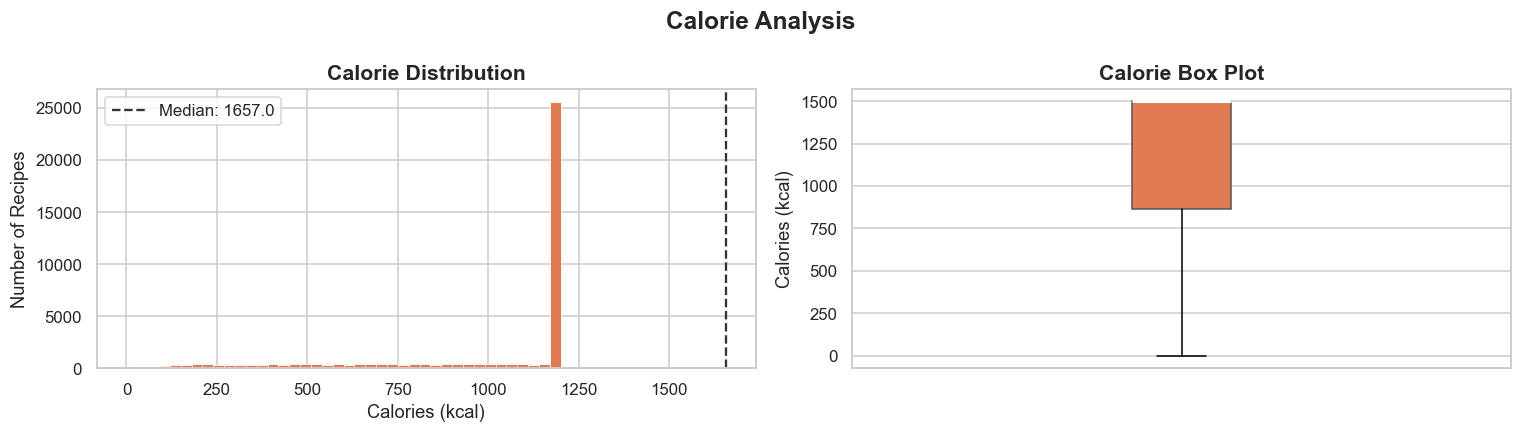

Mean   : 2139.1 kcal
Median : 1656.9 kcal
Std Dev: 1924.7 kcal


In [16]:
# 7a. Calorie distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["calories"].clip(0, 1200), bins=40,
             color="#E07B54", edgecolor="white", linewidth=0.5)
axes[0].axvline(df["calories"].median(), color="#333", linestyle="--",
                label="Median: " + str(round(df["calories"].median(), 0)))
axes[0].set_xlabel("Calories (kcal)", fontsize=12)
axes[0].set_ylabel("Number of Recipes", fontsize=12)
axes[0].set_title("Calorie Distribution", fontsize=14, fontweight="bold")
axes[0].legend()

axes[1].boxplot(df["calories"].clip(0, 1500), vert=True, patch_artist=True,
                boxprops=dict(facecolor="#E07B54", color="#555"),
                medianprops=dict(color="white", linewidth=2))
axes[1].set_ylabel("Calories (kcal)", fontsize=12)
axes[1].set_title("Calorie Box Plot", fontsize=14, fontweight="bold")
axes[1].set_xticks([])

plt.suptitle("Calorie Analysis", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

print("Mean   :", round(df["calories"].mean(), 1), "kcal")
print("Median :", round(df["calories"].median(), 1), "kcal")
print("Std Dev:", round(df["calories"].std(), 1), "kcal")


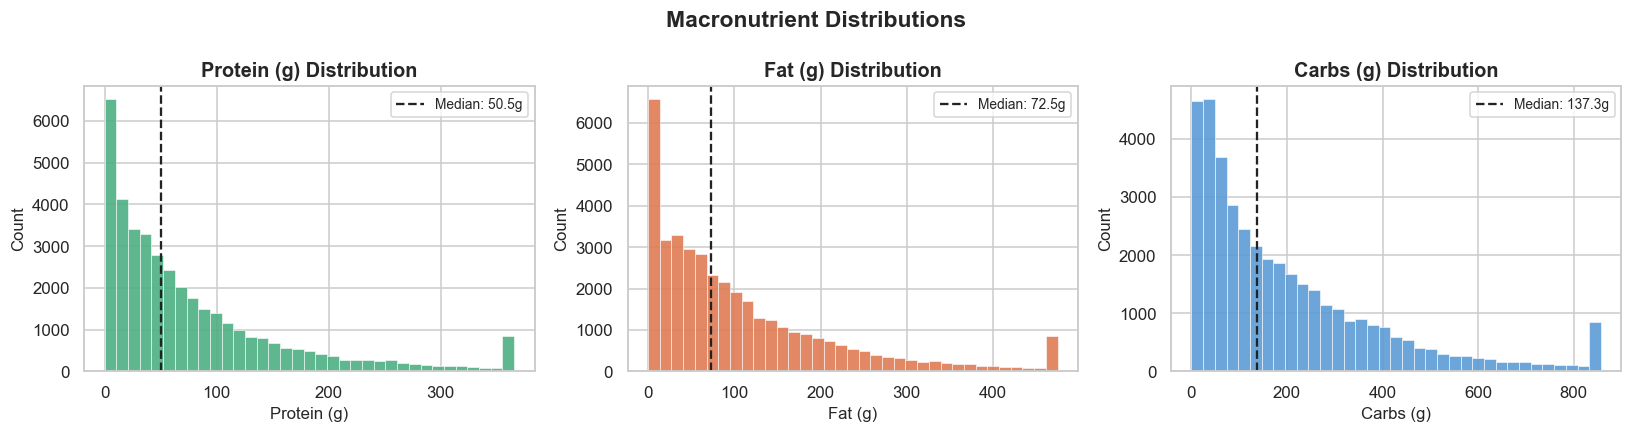

In [17]:
# 7b. Macronutrient distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
macros = [
    ("protein_g", "#4CAF82", "Protein (g)"),
    ("fat_g",     "#E07B54", "Fat (g)"),
    ("carbs_g",   "#5B9BD5", "Carbs (g)"),
]

for ax, (col, color, label) in zip(axes, macros):
    upper = df[col].quantile(0.98)
    ax.hist(df[col].clip(0, upper), bins=35,
            color=color, edgecolor="white", linewidth=0.4, alpha=0.9)
    ax.axvline(df[col].median(), color="#222", linestyle="--",
               label="Median: " + str(round(df[col].median(), 1)) + "g")
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(label + " Distribution", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)

plt.suptitle("Macronutrient Distributions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


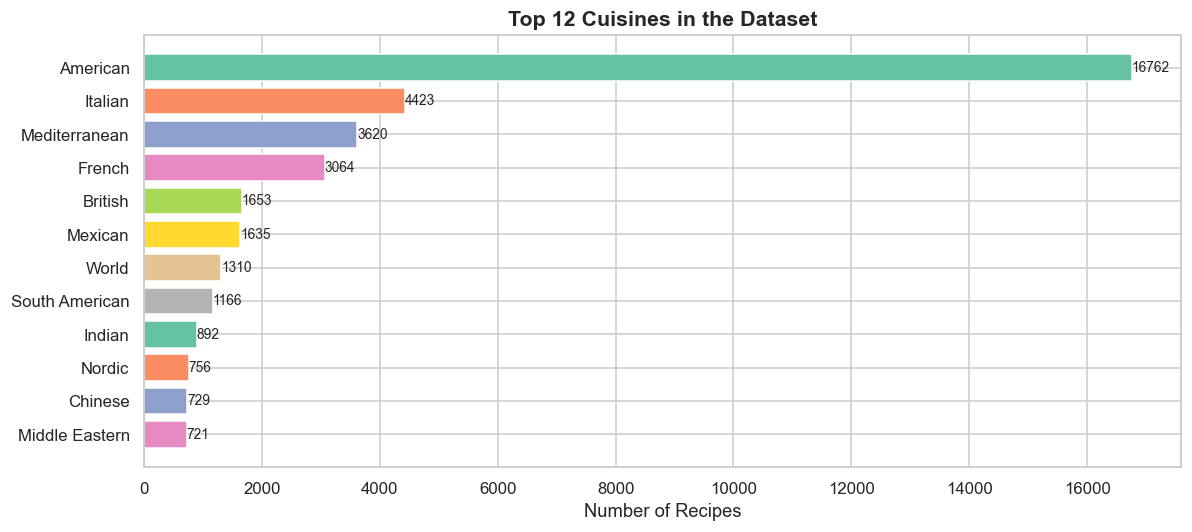

In [18]:
# 7c. Top cuisines (horizontal bar chart)
cuisine_counts = df["primary_cuisine"].value_counts().head(12)
palette = sns.color_palette("Set2", len(cuisine_counts))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(cuisine_counts.index[::-1], cuisine_counts.values[::-1], color=palette[::-1])
ax.set_xlabel("Number of Recipes", fontsize=12)
ax.set_title("Top 12 Cuisines in the Dataset", fontsize=14, fontweight="bold")
for bar, val in zip(bars, cuisine_counts.values[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
plt.tight_layout()
plt.show()


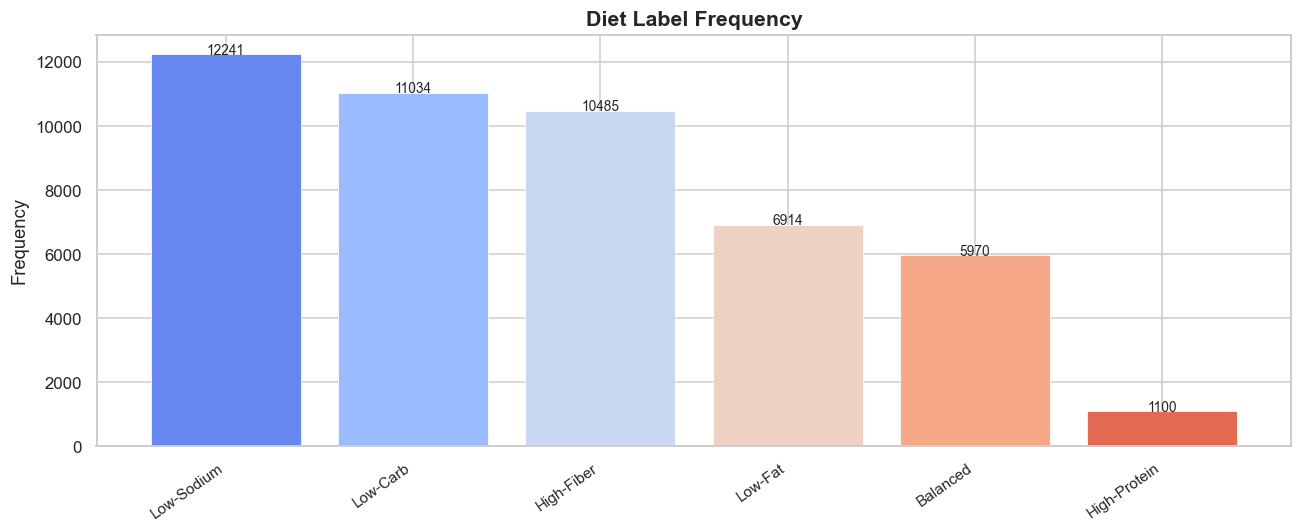

In [19]:
# 7d. Diet label frequency
all_labels = [l for sublist in df["diet_labels"] for l in sublist]
diet_counts = pd.Series(Counter(all_labels)).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 5))
colors = sns.color_palette("coolwarm", len(diet_counts))
ax.bar(diet_counts.index, diet_counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_ylabel("Frequency", fontsize=12)
ax.set_title("Diet Label Frequency", fontsize=14, fontweight="bold")
ax.set_xticklabels(diet_counts.index, rotation=35, ha="right", fontsize=10)
for i, v in enumerate(diet_counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()


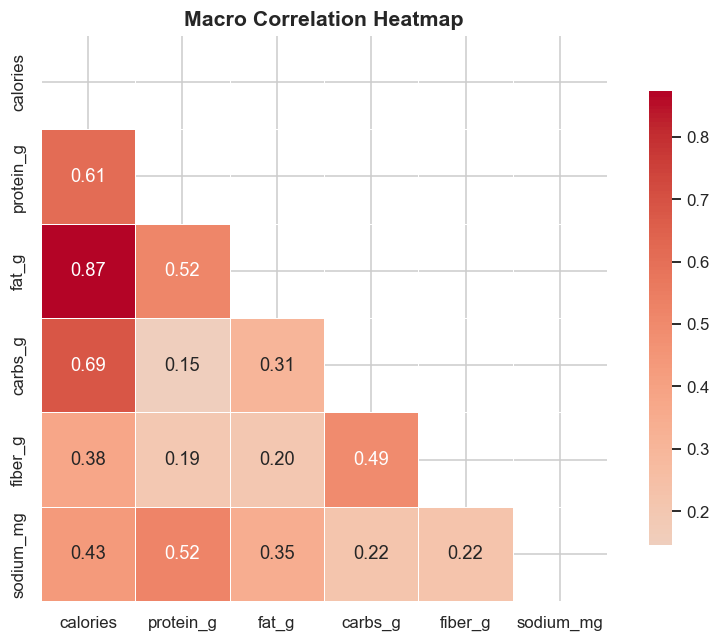

In [20]:
# 7e. Macro correlation heatmap
macro_cols = ["calories","protein_g","fat_g","carbs_g","fiber_g","sodium_mg"]
corr = df[macro_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Macro Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


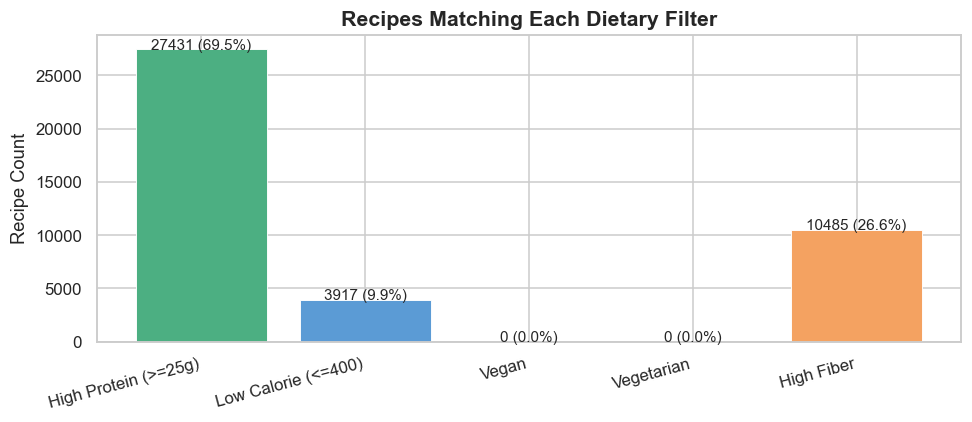

In [21]:
# 7f. Diet filter counts
filter_summary = {
    "High Protein (>=25g)": int(df["is_high_protein"].sum()),
    "Low Calorie (<=400)":  int(df["is_low_calorie"].sum()),
    "Vegan":                int(df["is_vegan"].sum()),
    "Vegetarian":           int(df["is_vegetarian"].sum()),
    "High Fiber":           int(df["is_high_fiber"].sum()),
}
fs = pd.Series(filter_summary)
colors = ["#4CAF82","#5B9BD5","#A8D5A2","#B5C8E2","#F4A261"]
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(fs.index, fs.values, color=colors, edgecolor="white", linewidth=0.6)
ax.set_ylabel("Recipe Count", fontsize=12)
ax.set_title("Recipes Matching Each Dietary Filter", fontsize=14, fontweight="bold")
for i, (key, v) in enumerate(filter_summary.items()):
    pct = v / len(df) * 100
    ax.text(i, v + 0.5, str(v) + " (" + str(round(pct, 1)) + "%)", ha="center", fontsize=10)
ax.set_xticklabels(fs.index, rotation=15, ha="right")
plt.tight_layout()
plt.show()


In [22]:
# 7g. Top 10 highest-protein recipes
top_protein = df.nlargest(10, "protein_g")[
    ["recipe_name","protein_g","calories","fat_g","carbs_g"]
].reset_index(drop=True)
top_protein.index += 1
print("Top 10 Highest-Protein Recipes:")
print(top_protein.to_string())


Top 10 Highest-Protein Recipes:
                                                       recipe_name  protein_g  calories   fat_g  carbs_g
1                                    BBQ Turkey Mixed Grill Dinner    1510.00  11300.10  529.95    38.46
2   Smokin', Drunkin', Flame-Broiled Turkey (Turkey on a Beer Can)    1480.49  10189.21  386.60    70.00
3                                      Quinoa, lentil & feta salad    1425.86  20912.30   98.32  3719.43
4                                             Maple Bourbon Turkey    1351.58   9794.73  421.80    37.49
5                             Texas Clod (Barbecued Beef Shoulder)    1299.92   9192.33  391.83    25.16
6                                              Turkey Gravy Pepper    1285.74   8836.96  338.63    83.98
7                      Roasted Shrimp with Champagne-Shallot Sauce    1284.09   7151.71  173.07    44.89
8                 Swiss Paleo’s Homemade Italian & Chorizo Sausage    1275.09  20366.78 1607.82    83.34
9                      

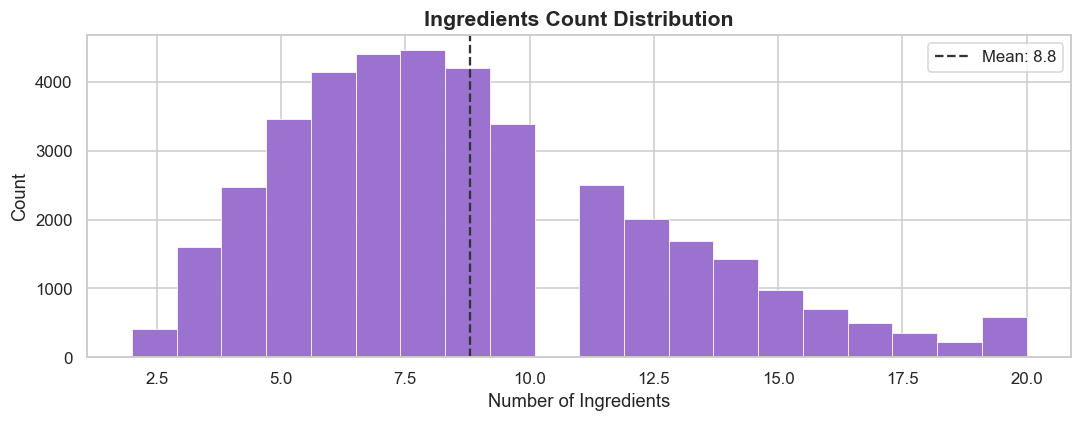

In [23]:
# 7h. Ingredient count distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["n_ingredients"].clip(0, 20), bins=20,
        color="#9B72CF", edgecolor="white", linewidth=0.5)
ax.axvline(df["n_ingredients"].mean(), linestyle="--", color="#333",
           label="Mean: " + str(round(df["n_ingredients"].mean(), 1)))
ax.set_xlabel("Number of Ingredients", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Ingredients Count Distribution", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## Step 8 — Save Clean Dataset

In [24]:
# Drop the temporary helper column
df_clean = df.drop(columns=["nutrients_dict"], errors="ignore")

Path("data").mkdir(exist_ok=True)
df_clean.to_csv("data/recipes_clean.csv", index=False)

print("Saved", len(df_clean), "rows to data/recipes_clean.csv")
print("Final columns (" + str(df_clean.shape[1]) + "):", list(df_clean.columns))


Saved 39447 rows to data/recipes_clean.csv
Final columns (32): ['recipe_name', 'source', 'url', 'servings', 'calories', 'total_weight_g', 'image_url', 'diet_labels', 'health_labels', 'cautions', 'cuisine_type', 'meal_type', 'dish_type', 'ingredient_lines', 'ingredients', 'total_nutrients', 'daily_values', 'digest', 'protein_g', 'fat_g', 'carbs_g', 'fiber_g', 'sodium_mg', 'ingredients_text', 'n_ingredients', 'is_high_protein', 'is_low_calorie', 'is_vegan', 'is_vegetarian', 'is_high_fiber', 'macro_ratio_protein', 'primary_cuisine']


In [25]:
# Final preview of clean dataset
df_clean[["recipe_name","primary_cuisine","calories","protein_g",
          "fat_g","carbs_g","is_high_protein","is_low_calorie"]].head(10)


,recipe_name,primary_cuisine,calories,protein_g,fat_g,carbs_g,is_high_protein,is_low_calorie
0,Classic Cabbage Slaw with Grandmother Shinn's Dressing,American,511.28,19.60,15.26,74.52,False,False
1,Black Bean Soup,American,1851.00,181.81,55.54,158.91,True,False
2,Eat for Eight Bucks: Tofu with Tomatoes and Cilantro Recipe,Asian,1643.76,101.24,102.62,103.41,True,False
3,Fried Chicken Banh Mi,South East Asian,8471.18,203.31,559.33,662.33,True,False
4,The Macaron Frappé,French,276.24,6.58,14.43,30.11,False,True
5,Cabbage au Gratin,French,678.60,22.56,52.95,20.37,False,False
6,Gingerbread Cookie Dough,American,2782.03,36.60,95.11,455.93,True,False
7,Sparkling Berry Lemonade,American,122.56,1.02,0.67,30.63,False,True
8,Thick and Creamy Chocolate Peanut Butter Breakfast Shake...,American,633.59,13.91,22.42,112.59,False,False
9,"Sour Cream, Cheddar and Bacon Deviled Eggs",American,1171.77,63.50,98.31,4.52,True,False
